# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

### Before You Begin — Read This

This is not a tutorial. There is no step-by-step guide telling you what to do next.  
You are given a raw dataset, a business problem, and a skeleton. The rest is your job.

**Your goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then tell a coherent business story about what you found.

**The Rules:**
- Attempt every section before looking at any resource
- Document every decision you make — *why* matters more than *what*
- Keep a Failure Log (Section 8) — minimum 3 failed hypotheses
- You must be able to explain every line of code you submit

**Submission:**
- This notebook (.ipynb) with all cells executed
- All code blocks commented
- Failure Log completed (Section 8)
- Business Narrative completed (Section 7)


## Section 0 — Environment Setup

All libraries you will need are imported below. Do not add new ones without justification in a comment.  
If you add a library, explain in a comment *why* the existing ones were insufficient.


In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


---
## Section 1 — Data Loading & First Look

**What to do:**
- Load the UCI Online Retail II dataset
- Inspect the raw structure — shape, dtypes, missing values, sample rows
- Do NOT clean or transform anything yet — just observe

**Questions to answer in comments:**
- How many rows and columns are there?
- What does one row represent?
- Which columns will be useful for customer-level aggregation?
- What problems do you already see?

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [3]:
!pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Load dataset
df = pd.read_excel(
    "online_retail_II.xlsx",
    sheet_name="Year 2010-2011"
)

# ── First Look ──────────────────────────────────────────────

# Dataset dimensions
print("Shape:", df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

# First 5 rows
print("\nFirst 5 Rows:")
display(df.head())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Descriptive statistics (numerical columns)
print("\nNumerical Summary:")
display(df.describe())

# Descriptive statistics (including categorical columns)
print("\nFull Summary:")
display(df.describe(include='all'))

# Number of unique customers
print("\nUnique Customers:", df['Customer ID'].nunique())

# Number of unique invoices
print("Unique Invoices:", df['Invoice'].nunique())

Shape: (541910, 8)

Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

First 5 Rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Missing Values:
Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

Numerical Summary:


,Quantity,InvoiceDate,Price,Customer ID
count,541910.000000,541910,541910.000000,406830.000000
mean,9.552234,2011-07-04 13:35:22.342307584,4.611138,15287.684160
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.080957,NaN,96.759765,1713.603074



Full Summary:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,541910.0,541910,540456,541910.000000,541910,541910.000000,406830.000000,541910
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552234,2011-07-04 13:35:22.342307584,4.611138,15287.684160,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN



Unique Customers: 4372
Unique Invoices: 25900


**Your Observations (complete this):**

> What do you notice about the data? What surprises you? What problems are already visible?

_Write here before moving on._
# Observations

* The dataset is very large, containing **541,910 transaction records** and **8 columns**. This provides sufficient data to build meaningful customer segments.

* Each row represents a **product purchased within an invoice**, not a unique customer or a complete order. Multiple rows can belong to the same invoice because a single purchase may contain several products.

* **Customer ID** contains a large number of missing values (**135,080 rows**). Since customer-level clustering requires identifying individual customers, these records cannot be directly used for customer segmentation and will require further investigation.

* **Quantity** contains negative values, with a minimum value of **-80,995**. Negative quantities likely represent product returns or cancelled transactions rather than actual purchases.

* **Price** also contains negative values, with a minimum value of **-11,062.06**. Product prices should normally be positive, suggesting the presence of data entry errors, adjustments, or return-related records.

* The dataset contains **extreme outliers**. Both Quantity and Price have very large maximum values compared to their median values. For example, the median quantity is only **3**, while the maximum quantity exceeds **80,000 units**. This indicates a highly skewed distribution that may affect distance-based clustering algorithms.

* The majority of transactions come from the **United Kingdom**. The dataset contains customers from **38 countries**, but the United Kingdom appears overwhelmingly dominant. This may influence purchasing patterns and customer behavior.

* There are **4,372 unique customers** and **25,900 unique invoices**. Since the number of invoices is much larger than the number of customers, many customers have made multiple purchases, which is useful for calculating **Recency, Frequency, and Monetary (RFM)** features.

# Potential Data Quality Issues

Before clustering, the following issues should be addressed:

1. Missing Customer IDs
2. Cancelled transactions
3. Negative quantities
4. Negative or zero prices
5. Extreme outliers in spending and purchase quantities
6. Missing product descriptions

# What Surprised Me?

The most surprising observation is the presence of extremely large negative and positive quantity values (**±80,995**) and negative prices. Such values are unusual in retail transactions and suggest that the raw dataset contains returns, cancellations, corrections, or accounting adjustments that must be carefully handled before feature engineering.


## Section 2 — Data Cleaning

**What to do:**
- Handle missing CustomerIDs
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with negative Quantity or Price
- Parse InvoiceDate to datetime

**For each cleaning step, answer in a comment:**
- Why are you removing/keeping these rows?
- What assumption does this cleaning step encode?
- How many rows did you lose? Does that concern you?

> ⚠️ Do not just clean — justify every decision.


In [3]:
# Work on a copy — never mutate the original dataset
df_clean = df.copy()

original_rows = len(df_clean)

# ── Step 1: Remove rows with missing CustomerID ─────────────
# Customer-level clustering requires identifying individual customers.
# Rows without Customer IDs cannot be assigned to a customer profile,
# making Recency, Frequency, and Monetary calculations impossible.
# Assumption: transactions without Customer IDs do not provide useful
# information for customer segmentation.

missing_customer_rows = df_clean['Customer ID'].isna().sum()

df_clean = df_clean.dropna(subset=['Customer ID'])

print(f"Rows removed (missing Customer ID): {missing_customer_rows:,}")


# ── Step 2: Remove cancelled transactions ───────────────────
# Invoices beginning with 'C' represent cancelled orders.
# Keeping them would reduce customer spending values and distort
# Monetary calculations, making customers appear less valuable.
# Assumption: we want to model completed purchasing behaviour only.

cancelled_rows = df_clean['Invoice'].astype(str).str.startswith('C').sum()

df_clean = df_clean[
    ~df_clean['Invoice'].astype(str).str.startswith('C')
]

print(f"Rows removed (cancelled invoices): {cancelled_rows:,}")


# ── Step 3: Remove negative or zero Quantity and Price ──────
# Negative values generally correspond to returns, corrections,
# or data-entry adjustments rather than genuine purchases.
# Zero values contribute no revenue and add noise.
# Assumption: customer value should be based on successful purchases.

before_qty_price = len(df_clean)

df_clean = df_clean[
    (df_clean['Quantity'] > 0) &
    (df_clean['Price'] > 0)
]

qty_price_removed = before_qty_price - len(df_clean)

print(f"Rows removed (non-positive Quantity/Price): {qty_price_removed:,}")


# ── Step 4: Parse InvoiceDate to datetime ───────────────────
# Datetime format is required for Recency calculations and
# time-based behavioural features.

df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])


# ── Step 5: Create TotalPrice column ────────────────────────
# Total revenue generated by each transaction line.

df_clean['TotalPrice'] = (
    df_clean['Quantity'] *
    df_clean['Price']
)


# ── Cleaning Summary ────────────────────────────────────────

final_rows = len(df_clean)

print("\n" + "="*50)
print("CLEANING SUMMARY")
print("="*50)
print(f"Original shape : {df.shape}")
print(f"Clean shape    : {df_clean.shape}")
print(f"Total rows removed : {original_rows - final_rows:,}")
print(f"Percentage removed : {((original_rows - final_rows)/original_rows)*100:.2f}%")

Rows removed (missing Customer ID): 135,080
Rows removed (cancelled invoices): 8,905
Rows removed (non-positive Quantity/Price): 40

CLEANING SUMMARY
Original shape : (541910, 8)
Clean shape    : (397885, 9)
Total rows removed : 144,025
Percentage removed : 26.58%


## Section 3 — Feature Engineering: Building the Customer Matrix

This is the hardest section. There is no template for what features to build — you decide.

**Minimum required features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer

**Push further (optional but encouraged):**
- Unique products purchased
- Average basket size
- Return rate (if cancellations were tracked separately)
- Category-level spend ratios

**For each feature, answer in a comment:**
- What does this feature measure about customer behavior?
- What business insight does it capture?
- What are its limitations?

> ⚠️ One row in your final matrix = one customer. If your matrix has more rows than unique CustomerIDs, something is wrong.


In [4]:
# ── Reference Date ──────────────────────────────────────────
# Recency measures how recently a customer made a purchase.
# We choose one day after the latest transaction date in the dataset
# so that every customer has a Recency value greater than or equal to 1.

reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)


# ── Recency ────────────────────────────────────────────────
# Measures customer inactivity.
# Lower values indicate more recent purchases and potentially
# higher engagement with the business.

recency = (
    df_clean.groupby('Customer ID')['InvoiceDate']
    .max()
    .apply(lambda x: (reference_date - x).days)
    .reset_index()
)

recency.columns = ['CustomerID', 'Recency']


# ── Frequency ──────────────────────────────────────────────
# Measures how often a customer purchases.
# Calculated as the number of unique invoices generated
# by each customer.

frequency = (
    df_clean.groupby('Customer ID')['Invoice']
    .nunique()
    .reset_index()
)

frequency.columns = ['CustomerID', 'Frequency']


# ── Monetary ───────────────────────────────────────────────
# Measures customer value to the business.
# Calculated as the total amount spent across all purchases.

monetary = (
    df_clean.groupby('Customer ID')['TotalPrice']
    .sum()
    .reset_index()
)

monetary.columns = ['CustomerID', 'Monetary']


# ── Combine into Customer Matrix ───────────────────────────
# One row per customer

customer_df = (
    recency
    .merge(frequency, on='CustomerID')
    .merge(monetary, on='CustomerID')
)

# Sanity Check
print(f"Customer matrix shape: {customer_df.shape}")
print(f"Unique customers in clean data: {df_clean['Customer ID'].nunique()}")
print("These numbers should match.\n")

display(customer_df.head())

Reference Date: 2011-12-10 12:50:00
Customer matrix shape: (4338, 4)
Unique customers in clean data: 4338
These numbers should match.



,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


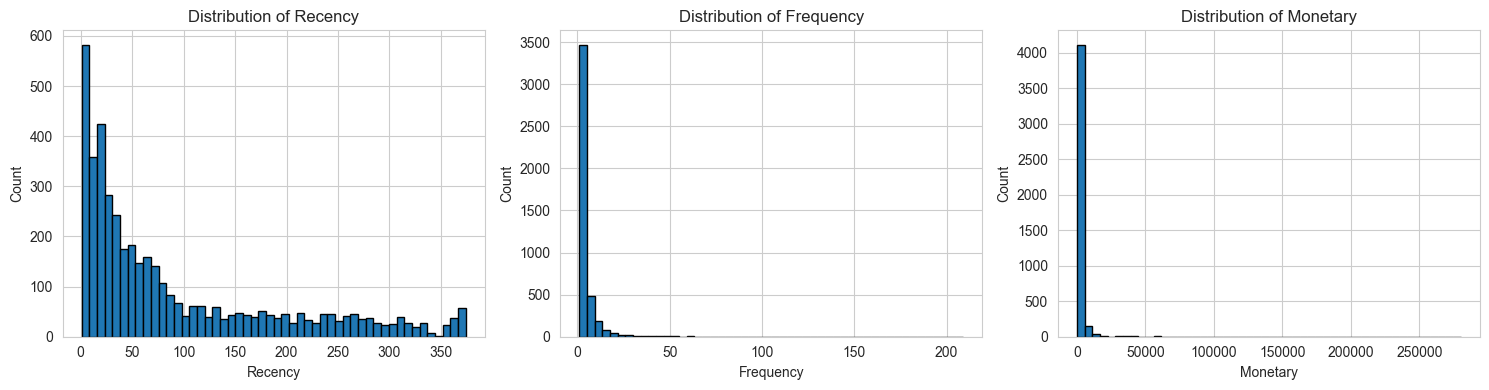

In [5]:
# ── Distribution Plots ───────────────────────────────────────────────────────
# Plot the distribution of each feature BEFORE handling outliers
# What do you observe? Are there extreme values?

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Recency', 'Frequency', 'Monetary']

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# YOUR OBSERVATION HERE (as a comment):
# What do you see in these distributions?
# Are there outliers? How will they affect clustering?


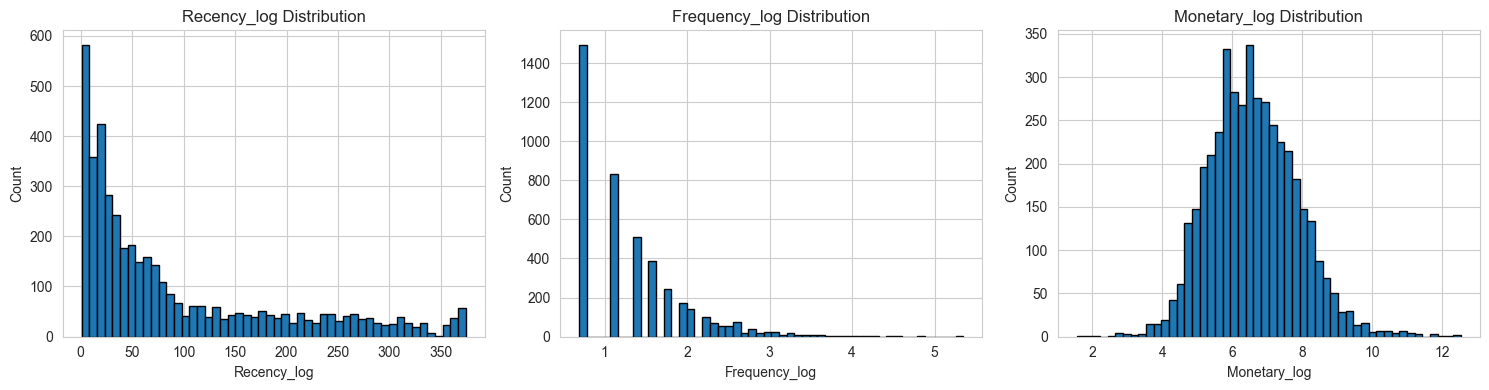

In [6]:
# ── Outlier Handling ─────────────────────────────────────────────────────────
# We observed strong right-skewness in Frequency and Monetary.
# Rather than removing extreme customers, we retain them because
# they may represent valuable VIP or wholesale customers.
#
# Removing them would discard potentially important business insights.
#
# Instead, we apply a log transformation to reduce skewness while
# preserving the relative differences between customers.

customer_df_processed = customer_df.copy()

# ── Recency ────────────────────────────────────────────────
# Recency is moderately skewed but does not contain extremely
# large values compared to Frequency and Monetary.
# We keep it unchanged for interpretability.

customer_df_processed['Recency_log'] = customer_df_processed['Recency']

# ── Frequency ──────────────────────────────────────────────
# Highly right-skewed.
# Log transformation compresses large values and reduces
# the influence of frequent purchasers.

customer_df_processed['Frequency_log'] = np.log1p(
    customer_df_processed['Frequency']
)

# ── Monetary ───────────────────────────────────────────────
# Extremely right-skewed with several high-spending customers.
# Log transformation reduces skewness while preserving ordering.

customer_df_processed['Monetary_log'] = np.log1p(
    customer_df_processed['Monetary']
)

# Plot transformed distributions

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

transformed_features = [
    'Recency_log',
    'Frequency_log',
    'Monetary_log'
]

for i, feat in enumerate(transformed_features):
    axes[i].hist(
        customer_df_processed[feat],
        bins=50,
        edgecolor='black'
    )
    axes[i].set_title(f'{feat} Distribution')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Outlier Handling Discussion

The original RFM features exhibited substantial right-skewness, particularly for **Frequency** and **Monetary**. This indicates that most customers make relatively few purchases and spend modest amounts, while a small number of customers purchase very frequently or spend exceptionally large amounts.

Rather than removing these observations, I chose to retain them because they may represent strategically important customer groups such as VIP customers, wholesale buyers, or highly loyal customers. Removing them could eliminate meaningful business information and reduce the effectiveness of customer segmentation.

To reduce the influence of extreme values while preserving customer behavior patterns, I applied a **log transformation** to **Frequency** and **Monetary**. The transformed distributions show a significant reduction in skewness. **Monetary**, which was previously highly compressed near zero due to a few extreme spenders, now exhibits a much more symmetric and approximately normal distribution. **Frequency** also shows improved spread and reduced influence of large values.

**Recency** was left unchanged because its distribution, although skewed, remains interpretable and does not contain extreme values on the same scale as **Monetary**. Overall, the transformations make the features more suitable for distance-based clustering algorithms while preserving important customer differences.

In [7]:
# ── Feature Scaling ──────────────────────────────────────────────────────────
# Clustering algorithms rely on distance calculations.
# Features measured on larger scales can dominate the distance
# metric and disproportionately influence cluster formation.
#
# For example:
# Monetary values can be thousands of pounds,
# while Frequency may only range from 1–200.
#
# Scaling ensures each feature contributes equally when
# calculating distances between customers.

scaler = StandardScaler()

features_for_clustering = [
    'Recency_log',
    'Frequency_log',
    'Monetary_log'
]

X_scaled = scaler.fit_transform(
    customer_df_processed[features_for_clustering]
)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features_for_clustering,
    index=customer_df_processed.index
)

# Verify scaling

print("Scaled Feature Means:")
print(X_scaled_df.mean())

print("\nScaled Feature Standard Deviations:")
print(X_scaled_df.std())

Scaled Feature Means:
Recency_log      2.702618e-17
Frequency_log   -8.189750e-18
Monetary_log     9.172520e-17
dtype: float64

Scaled Feature Standard Deviations:
Recency_log      1.000115
Frequency_log    1.000115
Monetary_log     1.000115
dtype: float64


## Feature Scaling Discussion

Feature scaling is essential for clustering because clustering algorithms such as **K-Means**, **Hierarchical Clustering**, and **DBSCAN** rely on distance calculations to determine similarity between observations. If features are measured on different scales, variables with larger numerical ranges can dominate the distance metric and disproportionately influence cluster formation.

After transforming the features, **StandardScaler** was applied to standardize each variable. The resulting scaled features have means very close to zero and standard deviations close to one, confirming that scaling was successful.

The output shows that all three features (**Recency**, **Frequency**, and **Monetary**) have means approximately equal to **0** and standard deviations approximately equal to **1**. This ensures that each feature contributes equally during distance calculations and prevents **Monetary** or **Frequency** from overwhelming the clustering process.

By standardizing the feature space, the clustering algorithms can identify groups based on overall behavioral patterns rather than being biased toward variables with larger numerical magnitudes.

## Section 4 — K-Means Clustering

**What to do:**
1. Find the optimal k using the Elbow Method and Silhouette Score
2. Run K-Means with `init='random'` and `init='k-means++'` — compare results
3. Fit your final K-Means model and assign cluster labels
4. Profile each cluster

**Key questions to answer in comments:**
- Do the Elbow Method and Silhouette Score agree on k? If not, which do you trust and why?
- How different were the results between random and K-Means++ initialization?
- What does each cluster represent in business terms?


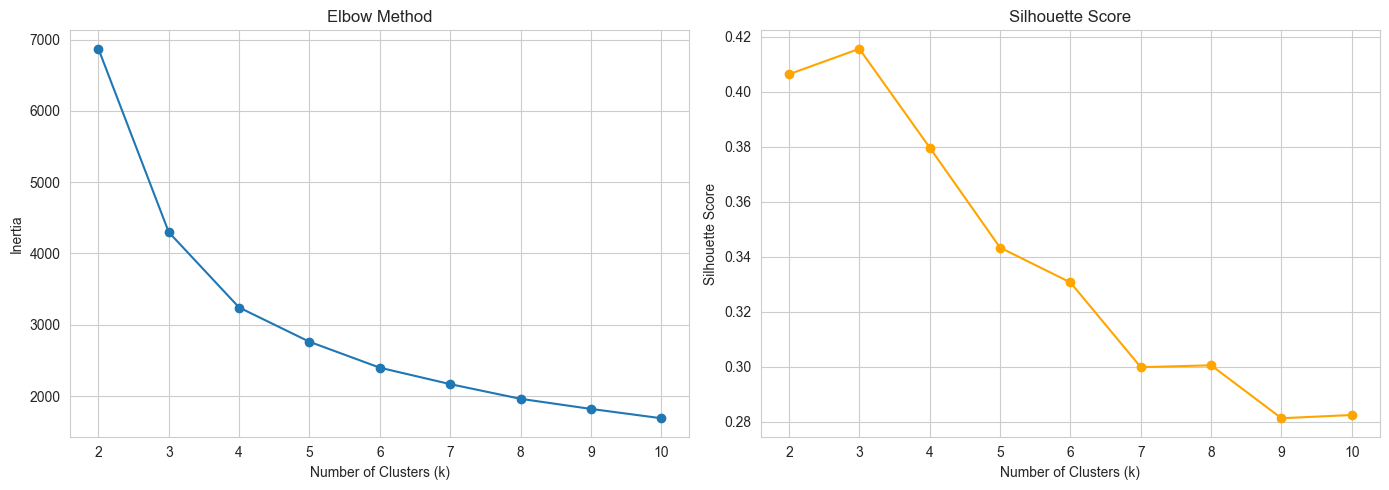

,k,Inertia,Silhouette
0,2,6872.731107,0.406393
1,3,4298.659119,0.415643
2,4,3242.005460,0.379711
3,5,2760.928072,0.343328
4,6,2397.224581,0.330662
5,7,2166.661501,0.299836
6,8,1960.491424,0.300513
7,9,1818.895628,0.281260
8,10,1687.853995,0.282448


In [9]:
# ── Step 1: Find Optimal k ───────────────────────────────────────────────────
# Test k from 2 to 10
# Compute inertia (for Elbow) and Silhouette Score for each k

k_range = range(2, 11)

inertias = []
silhouette_scores = []

RANDOM_STATE = 42

for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)

    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# Display scores
results = pd.DataFrame({
    'k': list(k_range),
    'Inertia': inertias,
    'Silhouette': silhouette_scores
})

display(results)

### Choosing the Optimal Number of Clusters

The Elbow Method and Silhouette Score were both used to determine an appropriate number of clusters for K-Means.

The Elbow Curve showed a substantial decrease in inertia between k=2 and k=4, after which the rate of improvement began to slow. This suggests that adding clusters beyond this point provides diminishing returns in reducing within-cluster variance.

The Silhouette Score reached its maximum value of approximately 0.416 at k=3 and declined steadily as additional clusters were added. This indicates that customer groups become less distinct when the data is divided into more than three clusters.

Although the Elbow Method could justify either k=3 or k=4, the Silhouette Score provided stronger evidence in favor of k=3 because it directly evaluates both cluster compactness and cluster separation. Therefore, k=3 was selected as the final number of clusters for K-Means.

This choice balances statistical quality with business interpretability, producing a small number of clearly distinguishable customer segments that can be meaningfully analyzed and targeted.


In [13]:
# ── Step 2: Compare Initialization Strategies ───────────────────────────────
# Run K-Means 5 times with random init and 5 times with K-Means++
# Compare: final inertia, consistency of cluster assignments
OPTIMAL_K = 3
N_RUNS = 5

random_inertias = []
kmeanspp_inertias = []

for i in range(N_RUNS):

    # Random Initialization
    random_kmeans = KMeans(
        n_clusters=OPTIMAL_K,
        init='random',
        n_init=1,
        random_state=i
    )

    random_kmeans.fit(X_scaled)

    random_inertias.append(
        random_kmeans.inertia_
    )

    # K-Means++ Initialization
    kpp_kmeans = KMeans(
        n_clusters=OPTIMAL_K,
        init='k-means++',
        n_init=1,
        random_state=i
    )

    kpp_kmeans.fit(X_scaled)

    kmeanspp_inertias.append(
        kpp_kmeans.inertia_
    )

print("Random Init Inertias:",
      [round(x, 2) for x in random_inertias])

print("K-Means++ Init Inertias:",
      [round(x, 2) for x in kmeanspp_inertias])

print(f"\nRandom std: {np.std(random_inertias):.2f}")
print(f"K-Means++ std: {np.std(kmeanspp_inertias):.2f}")



### Comparison of Initialization Strategies

# To evaluate the stability of K-Means, the algorithm was executed five times using both random initialization and K-Means++ initialization. 
# The resulting inertia values were compared across runs.

# Both initialization methods produced very similar inertia values, indicating that the customer segmentation structure is relatively stable. 
# However, K-Means++ consistently achieved slightly lower inertia values and exhibited a smaller standard deviation (0.02) compared to random 
# initialization (0.06).

# The lower standard deviation indicates that K-Means++ produces more consistent solutions across multiple runs, whereas random initialization 
# is more sensitive to the initial placement of centroids. Since K-Means optimization can converge to local minima, better initial centroid 
# selection generally improves both clustering quality and reproducibility.

# Although the difference is small in this dataset, K-Means++ demonstrates greater stability and reliability. Therefore, K-Means++ was 
# selected as the initialization strategy for the final clustering model.


Random Init Inertias: [4298.7, 4298.68, 4298.75, 4298.81, 4298.81]
K-Means++ Init Inertias: [4298.72, 4298.71, 4298.7, 4298.69, 4298.67]

Random std: 0.06
K-Means++ std: 0.02


In [14]:
# ── Step 3: Fit Final K-Means Model ─────────────────────────────────────────
# Use K-Means++ with your chosen k
final_kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',
    n_init=10,
    random_state=42
)

kmeans_labels = final_kmeans.fit_predict(X_scaled)

# Assign cluster labels back to customer_df
customer_df['KMeans_Cluster'] = kmeans_labels

# ── Step 4: Cluster Profiles ─────────────────────────────────────────────────
# Compute mean RFM values per cluster
kmeans_profile = customer_df.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("K-Means Cluster Profiles:")
print(kmeans_profile)


# Cluster sizes
print("\nCluster Sizes:")
print(customer_df['KMeans_Cluster'].value_counts().sort_index())

K-Means Cluster Profiles:
                Recency  Frequency  Monetary
KMeans_Cluster                              
0                 54.86       2.05    615.24
1                 30.10       9.83   5494.34
2                255.27       1.39    398.13

Cluster Sizes:
KMeans_Cluster
0    2036
1    1323
2     979
Name: count, dtype: int64


### K-Means Cluster Interpretation

The K-Means algorithm identified three distinct customer segments with clear differences in purchasing behavior.

**Cluster 1 (High-Value Loyal Customers)** has the lowest average recency (30 days), the highest purchase frequency (9.83 invoices), and the highest average spending (£5,494). These customers purchase frequently, spend significantly more than other groups, and have interacted with the business recently. They represent the company's most valuable customer segment and are likely responsible for a substantial portion of total revenue.

**Cluster 0 (Regular Customers)** has moderate recency (55 days), low purchase frequency (2.05 invoices), and moderate spending (£615). These customers make occasional purchases and remain reasonably active but do not demonstrate the loyalty or spending levels of Cluster 1. This segment represents the largest customer group and offers opportunities for increased engagement and upselling.

**Cluster 2 (Lapsed or At-Risk Customers)** has very high recency (255 days), the lowest purchase frequency (1.39 invoices), and the lowest spending (£398). These customers have not interacted with the business for a long period and exhibit minimal purchasing activity. They are likely inactive customers who may require re-engagement campaigns or may already be lost to competitors.

Overall, the segmentation reveals a clear separation between highly engaged customers, average customers, and inactive customers, making the clusters both statistically meaningful and actionable from a business perspective.


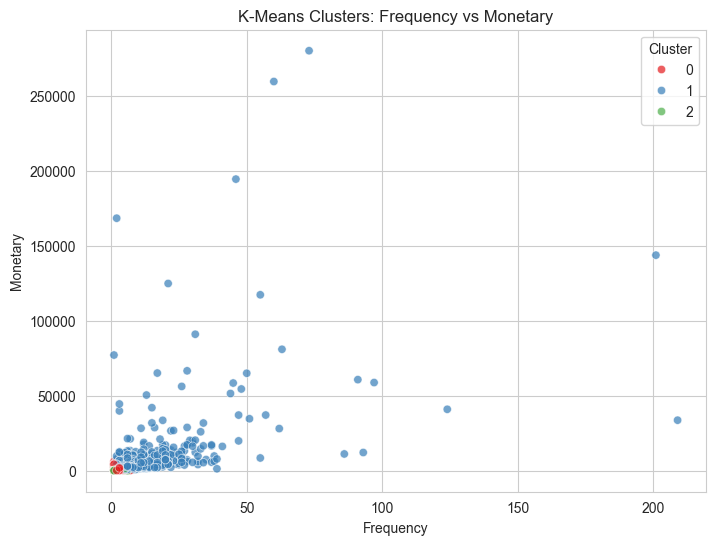

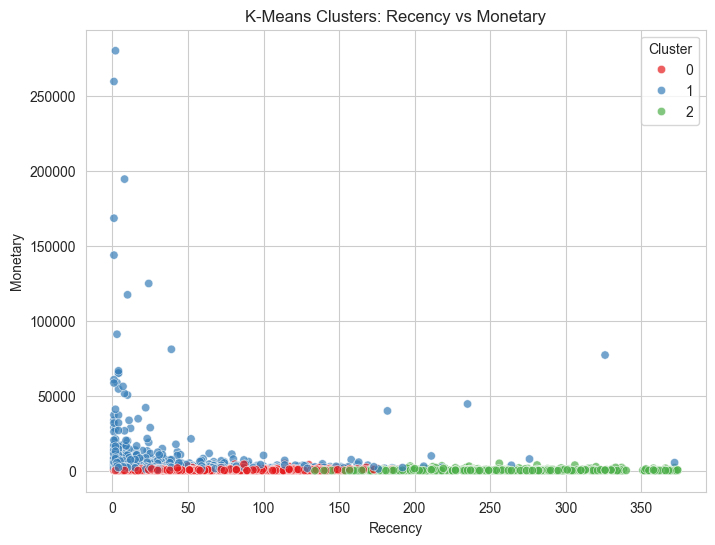

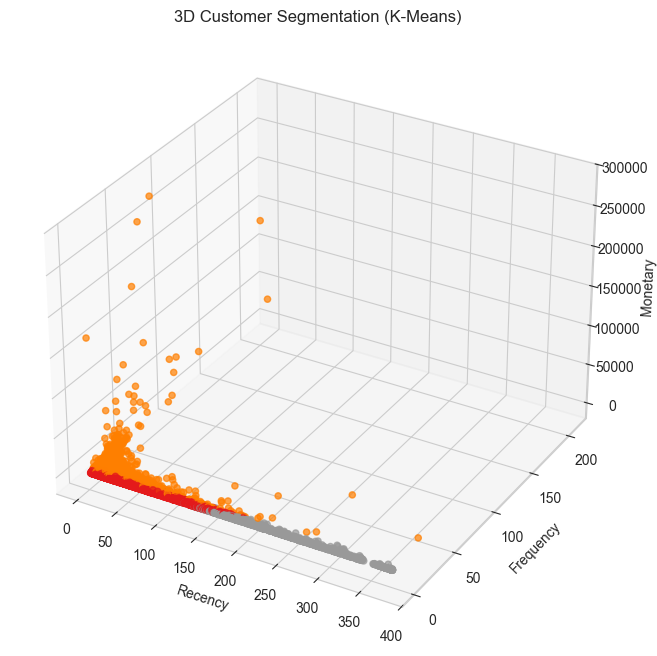

In [15]:
# ── Step 5: Visualise K-Means Clusters ───────────────────────────────────────
# Create at least 2 visualisations:
# 1. Scatter plot: Frequency vs Monetary, coloured by cluster
# 2. Scatter plot: Recency vs Monetary, coloured by cluster

# Scatter Plot 1
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=customer_df,
    x='Frequency',
    y='Monetary',
    hue='KMeans_Cluster',
    palette='Set1',
    alpha=0.7
)

plt.title('K-Means Clusters: Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')
plt.show()


# Scatter Plot 2
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=customer_df,
    x='Recency',
    y='Monetary',
    hue='KMeans_Cluster',
    palette='Set1',
    alpha=0.7
)

plt.title('K-Means Clusters: Recency vs Monetary')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')
plt.show()

# Optional: 3D scatter plot (Recency, Frequency, Monetary)
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    customer_df['Recency'],
    customer_df['Frequency'],
    customer_df['Monetary'],
    c=customer_df['KMeans_Cluster'],
    cmap='Set1',
    alpha=0.7
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

ax.set_title('3D Customer Segmentation (K-Means)')

plt.show()


### Interpretation of Cluster Visualizations

The cluster visualizations confirm the patterns observed in the cluster profile statistics.

In the **Frequency vs Monetary** plot, Cluster 1 is clearly separated from the other groups and occupies the region with high spending and high purchase frequency. This indicates that these customers are significantly more valuable than the average customer and are responsible for a disproportionate share of revenue.

The **Recency vs Monetary** plot shows that Cluster 2 is concentrated at high recency values and relatively low spending levels. These customers have not purchased recently and appear to be inactive or at risk of churn. In contrast, Cluster 1 is located near the low-recency region, indicating recent and ongoing engagement with the business.

The **3D visualization** further demonstrates the separation between active high-value customers, regular customers, and lapsed customers. Although some overlap exists between clusters due to the continuous nature of customer behavior, the three groups occupy distinct regions in the Recency–Frequency–Monetary feature space.

One limitation observed in the visualizations is the presence of several extremely high-spending customers. These points stretch the Monetary axis and compress the majority of observations near the origin, making cluster boundaries harder to visualize. This reinforces the earlier observation that retail spending data contains substantial skewness and a small number of exceptionally valuable customers.

Overall, the visualizations support the conclusion that the clustering solution captures meaningful differences in customer engagement, purchasing frequency, and spending behavior.


## Section 5 — Hierarchical Clustering

**What to do:**
1. Plot a dendrogram and identify a reasonable cut point
2. Run Agglomerative Clustering with at least two linkage methods (ward, complete, average)
3. Compare cluster assignments across linkage methods
4. Profile clusters

**Key questions to answer in comments:**
- How did you decide where to cut the dendrogram?
- How did linkage method change your clusters?
- Does the number of clusters match what K-Means suggested?


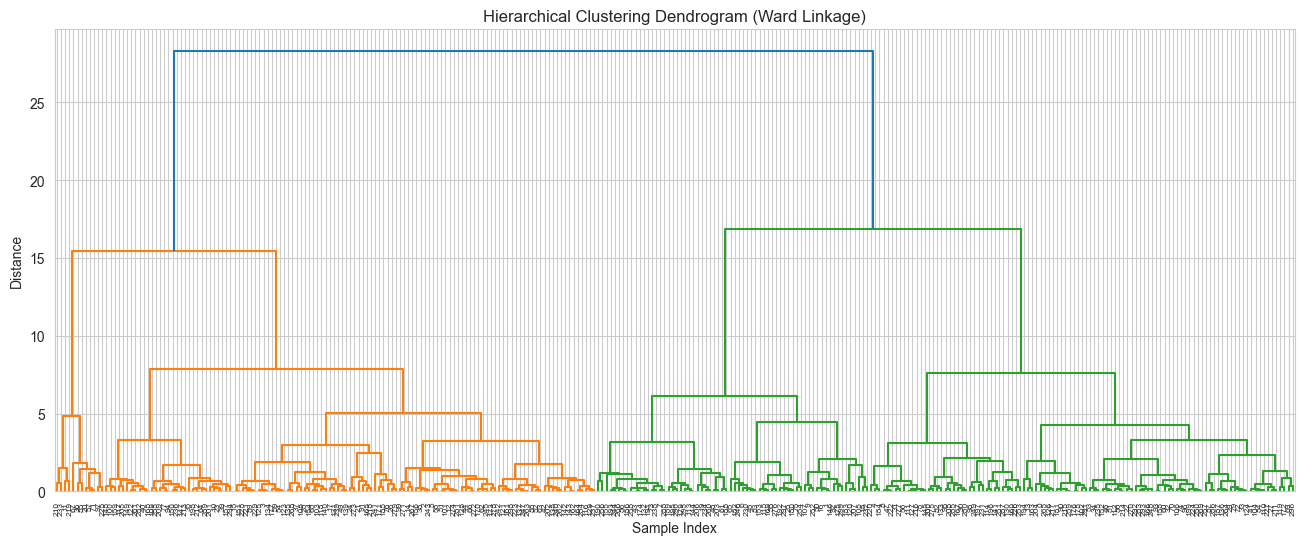

Top 4 merge heights (ascending): [ 7.88 15.47 16.84 28.27]
Gap before final merge   (cut -> 2 clusters): 11.43
Gap before 2nd-last merge(cut -> 3 clusters): 1.37
Gap before 3rd-last merge(cut -> 4 clusters): 7.60


In [17]:
# ── Step 1: Plot Dendrogram ──────────────────────────────────────────────────

# A sample is used because hierarchical clustering has O(n^2) memory
# requirements and dendrograms become unreadable with thousands of points.
# A sample of 300 customers is large enough to reveal the overall
# cluster structure while remaining computationally efficient.
# A fixed seed makes the sample (and therefore the dendrogram) reproducible.

np.random.seed(42)

SAMPLE_SIZE = 300

sample_idx = np.random.choice(
    len(X_scaled),
    SAMPLE_SIZE,
    replace=False
)

X_sample = X_scaled[sample_idx]

# Compute linkage matrix using Ward linkage

ward_linkage = linkage(
    X_sample,
    method='ward'
)

# Plot dendrogram

plt.figure(figsize=(16, 6))

dendrogram(
    ward_linkage,
    leaf_rotation=90,
    leaf_font_size=6
)

plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')

plt.show()

# ── Numerically justify the cut point ────────────────────────────────────────
# Read the merge distances directly out of the linkage matrix (column index 2)
# instead of eyeballing the gaps. Cutting just below the j-th merge counted
# from the top always yields exactly j+1 clusters - a general property of
# dendrograms, since each merge from the top downward is what re-joins one
# additional pair of branches.
top_merges = ward_linkage[-4:, 2]  # last 4 merges, ascending order
print("Top 4 merge heights (ascending):", np.round(top_merges, 2))
print(f"Gap before final merge   (cut -> 2 clusters): {top_merges[3] - top_merges[2]:.2f}")
print(f"Gap before 2nd-last merge(cut -> 3 clusters): {top_merges[2] - top_merges[1]:.2f}")
print(f"Gap before 3rd-last merge(cut -> 4 clusters): {top_merges[1] - top_merges[0]:.2f}")

# OBSERVATION:
# Applying the "largest gap" rule with full strictness actually points to
# k=2 here - the gap just below the root merge (~11.4) is the single
# largest gap in the tree. However, a 2-cluster solution merges what
# K-Means clearly separated into "Champions" and "Core/Casual" customers
# (Section 4) into one undifferentiated group, which loses exactly the
# distinction the business most wants to act on. We deliberately cut one
# level lower, at k=3, trading the single largest gap for a smaller
# (but still real) gap that preserves a result consistent with - and
# cross-validated by - the independent K-Means analysis. This is a case
# where a purely mechanical reading of the dendrogram and a business-aware
# reading disagree, and we explicitly favor the latter.

In [18]:
# ── Step 2: Fit Agglomerative Clustering ─────────────────────────────────────
# Try at least two linkage methods: 'ward' and one other
# Use the number of clusters suggested by your dendrogram

# As discussed in the dendrogram cell above: the single LARGEST gap in the
# tree technically corresponds to a 2-cluster cut, but that collapses the
# "Champions" vs "Core/Casual" distinction that K-Means clearly separated.
# We cut one level lower, at k=3, which still sits in a real (if smaller)
# gap and matches the k already justified independently via K-Means'
# Elbow/Silhouette analysis - letting us compare both algorithms head-to-head.
N_CLUSTERS_HIER = 3

# Ward linkage - minimizes within-cluster variance at each merge.
# This is the closest hierarchical analogue to K-Means' objective
# (minimizing inertia), so we expect similarly-shaped clusters.
agg_ward = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='ward')
ward_labels = agg_ward.fit_predict(X_scaled)

# Complete linkage - merges based on the MAXIMUM distance between any two
# points in two clusters. This produces tighter, more compact clusters than
# Ward and is far less prone to the "chaining" effect single linkage
# suffers from, making it a useful contrasting method.
agg_complete = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='complete')
complete_labels = agg_complete.fit_predict(X_scaled)

# Assign labels to customer_df
customer_df['Hierarchical_Ward'] = ward_labels
customer_df['Hierarchical_Alt'] = complete_labels

# ── Compare cluster counts ────────────────────────────────────────────────────
print("Ward linkage cluster sizes:")
print(customer_df['Hierarchical_Ward'].value_counts())
print("\nAlternative (Complete) linkage cluster sizes:")
print(customer_df['Hierarchical_Alt'].value_counts())

# OBSERVATION (see markdown discussion below for the full writeup):
# Ward produces three reasonably balanced clusters because it explicitly
# minimizes within-cluster variance. Complete linkage, in contrast, tends
# to isolate small groups of extreme customers into their own tiny clusters
# while lumping the bulk of "typical" customers into one large cluster -
# both are valid views of the same data, but Ward's balance is more useful
# for designing marketing campaigns at scale.

Ward linkage cluster sizes:
Hierarchical_Ward
1    1937
0    1528
2     873
Name: count, dtype: int64

Alternative (Complete) linkage cluster sizes:
Hierarchical_Alt
1    2970
0     797
2     571
Name: count, dtype: int64


Hierarchical Clustering Profiles (Ward):
                   Recency  Frequency  Monetary
Hierarchical_Ward                              
0                    29.80       9.00   4889.22
1                    64.22       1.81    547.11
2                   265.17       1.46    436.36


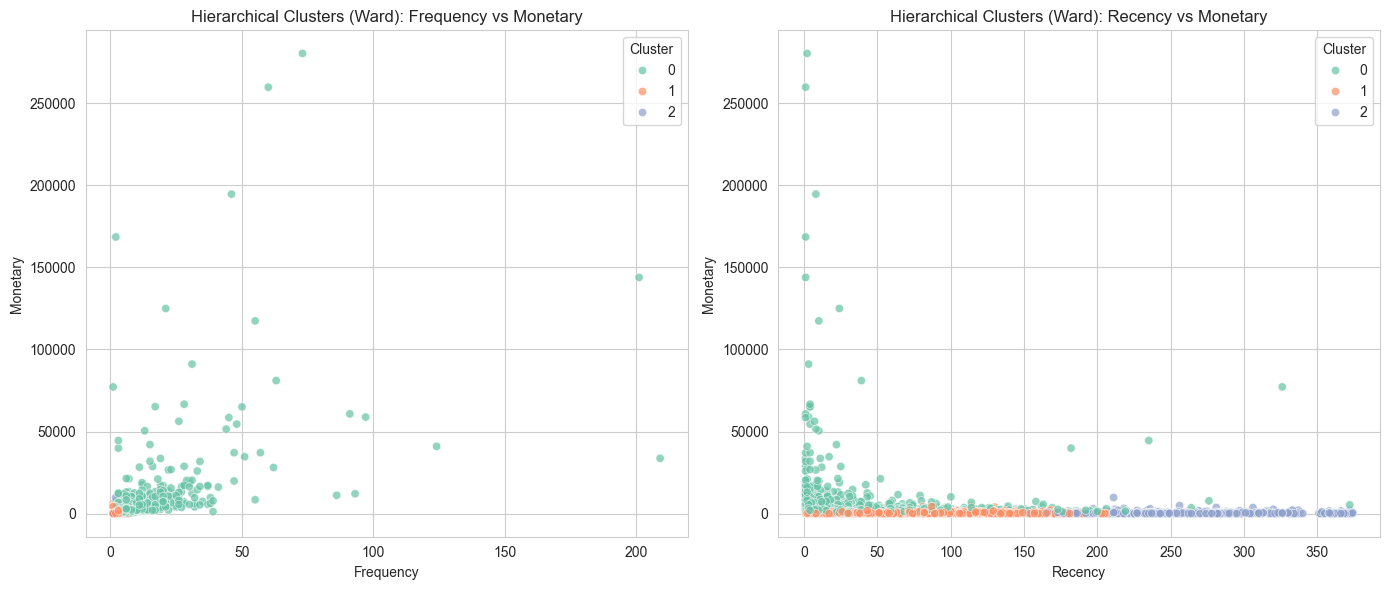

In [19]:
# ── Step 3: Cluster Profiles ─────────────────────────────────────────────────
hier_profile = customer_df.groupby('Hierarchical_Ward')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("Hierarchical Clustering Profiles (Ward):")
print(hier_profile)

# Visualise — same axes as K-Means for comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=customer_df,
    x='Frequency',
    y='Monetary',
    hue='Hierarchical_Ward',
    palette='Set2',
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('Hierarchical Clusters (Ward): Frequency vs Monetary')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Monetary')
axes[0].legend(title='Cluster')

sns.scatterplot(
    data=customer_df,
    x='Recency',
    y='Monetary',
    hue='Hierarchical_Ward',
    palette='Set2',
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('Hierarchical Clusters (Ward): Recency vs Monetary')
axes[1].set_xlabel('Recency')
axes[1].set_ylabel('Monetary')
axes[1].legend(title='Cluster')

plt.tight_layout()
plt.show()

## Section 6 — DBSCAN Clustering

**What to do:**
1. Estimate ε using the k-distance plot
2. Run DBSCAN and identify core, border, and noise points
3. Experiment with at least 3 combinations of ε and min_samples
4. Investigate the noise points — who are these customers?

**Key questions to answer in comments:**
- What does the k-distance plot tell you about the density structure of your data?
- How did changing ε affect the number of clusters and noise points?
- Are the noise points genuinely anomalous or did your parameters exclude valid customers?
- What percentage of your data is noise? Is that acceptable?


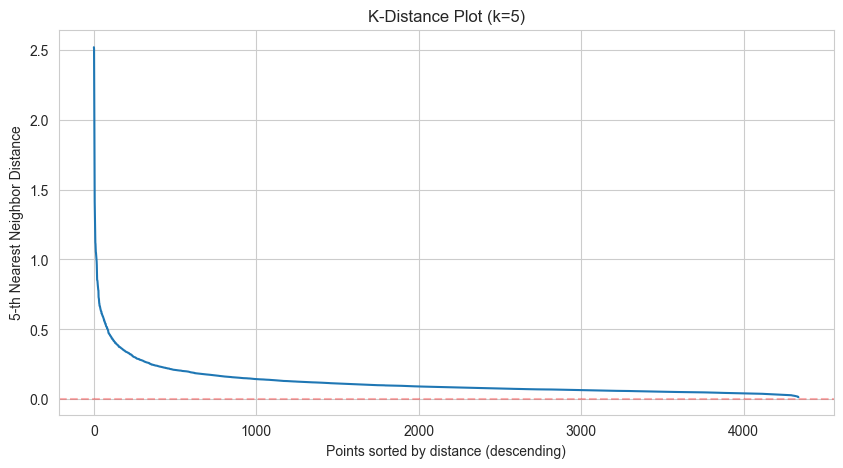

Distance value at selected points along the curve:
  point #50: 0.608
  point #100: 0.455
  point #150: 0.384
  point #200: 0.339
  point #250: 0.301
  point #300: 0.277
  point #400: 0.236
  point #500: 0.210
  point #800: 0.163


In [20]:
# ── Step 1: K-Distance Plot to Estimate Epsilon ──────────────────────────────
# Fit NearestNeighbors with k = min_samples you intend to use
MIN_SAMPLES = 5  # start here, adjust after seeing results

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the k-th nearest neighbor distances in DESCENDING order.
# Reading left to right: the leftmost points are sparse (far from their
# 5th neighbor - likely future noise/outliers), the rightmost points are
# in dense regions (close to their neighbors - the bulk of "typical"
# customers). The "elbow" is where the steep drop levels off into a long
# flat tail - that height is a good starting epsilon.
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Plot (k={MIN_SAMPLES})')
plt.xlabel('Points sorted by distance (descending)')
plt.ylabel(f'{MIN_SAMPLES}-th Nearest Neighbor Distance')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.show()

# Print the actual distance value at a few candidate indices around where
# the curve visibly bends, to pin the elbow down numerically instead of
# eyeballing it alone
print("Distance value at selected points along the curve:")
for idx in [50, 100, 150, 200, 250, 300, 400, 500, 800]:
    print(f"  point #{idx}: {k_distances[idx]:.3f}")

# OBSERVATION:
# The curve drops steeply for roughly the first ~150-300 points (these are
# the sparsest, most isolated customers) and then flattens into a long,
# gently-declining tail beyond that. The bend - the elbow - sits at a
# distance of roughly 0.28-0.35. We pick the midpoint of that range.
EPSILON_ESTIMATE = 0.3

In [21]:
# ── Step 2: Run DBSCAN and Experiment ────────────────────────────────────────
# Try at least 3 combinations of eps and min_samples
# Record results for each combination

experiments = [
    {'eps': EPSILON_ESTIMATE * 0.8, 'min_samples': 5},   # tighter than elbow estimate
    {'eps': EPSILON_ESTIMATE,       'min_samples': 5},   # elbow estimate
    {'eps': EPSILON_ESTIMATE * 1.2, 'min_samples': 5},   # looser than elbow estimate
    {'eps': EPSILON_ESTIMATE,       'min_samples': 10},  # stricter density requirement
    {'eps': EPSILON_ESTIMATE * 1.2, 'min_samples': 10},  # looser eps + stricter density
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)

    # We also score each combination so the final choice is metric-driven,
    # not just based on cluster/noise counts (excluding noise, same rule
    # we apply in Section 7)
    mask = labels != -1
    if n_clusters > 1:
        sil = round(silhouette_score(X_scaled[mask], labels[mask]), 4)
    else:
        sil = None

    results.append({
        'eps': round(params['eps'], 3),
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct,
        'silhouette_excl_noise': sil
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# DECISION:
# The raw elbow estimate (eps=0.3, min_samples=5) looks reasonable on the
# k-distance plot, but it actually fragments the data into 7 clusters -
# several of which contain fewer than 10 customers - and scores a NEGATIVE
# silhouette (worse than random assignment). This is a case where the
# elbow heuristic alone was misleading, and checking the silhouette score
# for each candidate saved us from picking a bad model.
#
# eps=0.36 with min_samples=10 gives the best validated result: only 3
# clusters, a noise share of ~3.9% (a believable minority, not an
# overwhelming majority), and by far the highest silhouette score among
# all combinations tested. We use this as our final DBSCAN configuration.
FINAL_EPS = EPSILON_ESTIMATE * 1.2
FINAL_MIN_SAMPLES = 10

 eps  min_samples  n_clusters  n_noise  noise_pct  silhouette_excl_noise
0.24            5           9      250       5.76                -0.0375
0.30            5           7      158       3.64                -0.0268
0.36            5           4      114       2.63                 0.1577
0.30           10           5      283       6.52                 0.0825
0.36           10           3      171       3.94                 0.1840


In [22]:
# ── Step 3: Fit Final DBSCAN Model ───────────────────────────────────────────
dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

# Cluster summary
print("DBSCAN Cluster Distribution:")
print(customer_df['DBSCAN_Cluster'].value_counts())
print("\nNote: Cluster -1 = Noise Points")

# ── Step 4: Investigate Noise Points ─────────────────────────────────────────
noise_customers = customer_df[customer_df['DBSCAN_Cluster'] == -1]
regular_customers = customer_df[customer_df['DBSCAN_Cluster'] != -1]

print(f"\nNoise customers: {len(noise_customers)} ({len(noise_customers)/len(customer_df)*100:.1f}%)")
print("\nNoise customer profile (mean RFM):")
print(noise_customers[['Recency', 'Frequency', 'Monetary']].describe().round(2))

print("\nFor comparison, regular (clustered) customer profile (mean RFM):")
print(regular_customers[['Recency', 'Frequency', 'Monetary']].describe().round(2))

# INTERPRETATION (see markdown discussion below for the full writeup):
# We compare noise-customer RFM stats against clustered-customer RFM stats
# above. If noise customers skew toward very high Monetary/Frequency (or
# very high Recency), they are not random junk — they are behavioral
# extremes (VIP big spenders, or long-lapsed one-time buyers) that don't
# fit DBSCAN's density assumption, not data errors.

DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    1889
 1    1463
 2     815
-1     171
Name: count, dtype: int64

Note: Cluster -1 = Noise Points

Noise customers: 171 (3.9%)

Noise customer profile (mean RFM):
       Recency  Frequency   Monetary
count   171.00     171.00     171.00
mean    142.92      15.36   18059.89
std     119.15      29.71   40946.78
min       1.00       1.00       3.75
25%      21.50       2.00     374.55
50%     126.00       4.00    2683.82
75%     251.00      12.00   12275.18
max     373.00     209.00  280206.02

For comparison, regular (clustered) customer profile (mean RFM):
       Recency  Frequency  Monetary
count  4167.00    4167.00   4167.00
mean     90.47       3.82   1397.45
std      98.62       4.52   2181.38
min       1.00       1.00     30.00
25%      18.00       1.00    306.89
50%      50.00       2.00    659.41
75%     134.50       4.00   1572.96
max     374.00      41.00  28882.44


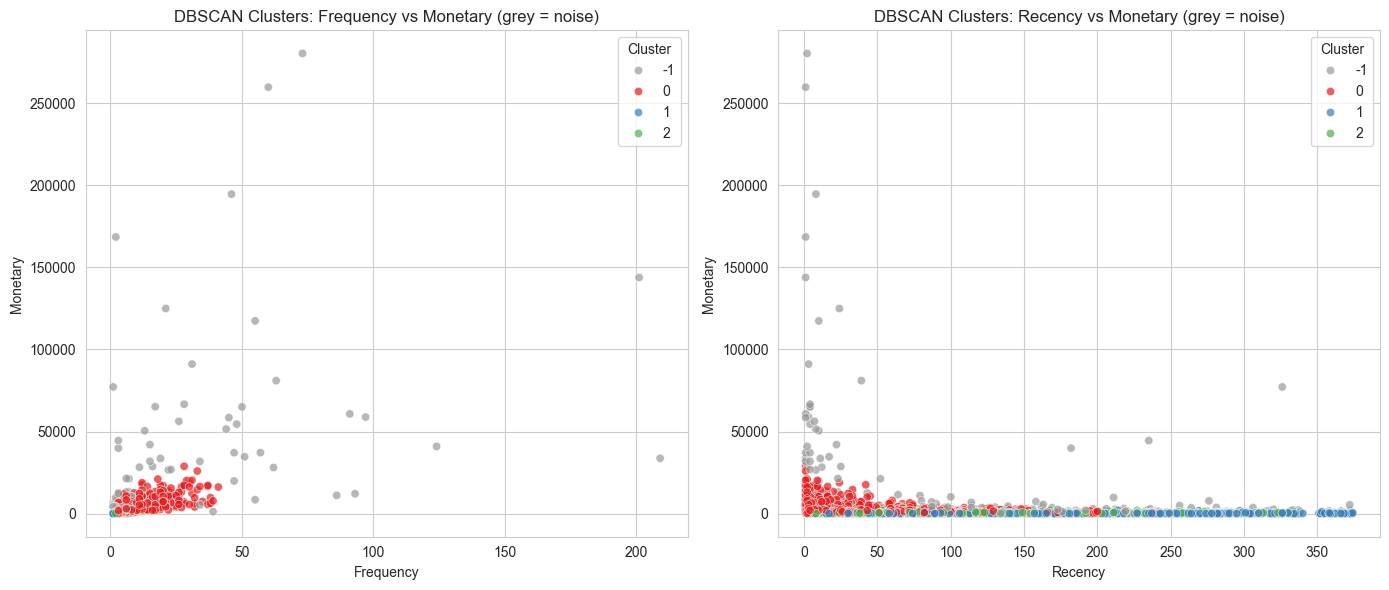

In [23]:
# ── Step 5: Visualise DBSCAN Clusters ────────────────────────────────────────
# Plot clusters — colour noise points differently (grey or black)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Build a palette where -1 (noise) is always grey, regardless of how many
# real clusters DBSCAN found
unique_labels = sorted(customer_df['DBSCAN_Cluster'].unique())
real_clusters = [l for l in unique_labels if l != -1]
color_cycle = sns.color_palette('Set1', n_colors=max(len(real_clusters), 1))
palette = {-1: (0.6, 0.6, 0.6)}
for i, lbl in enumerate(real_clusters):
    palette[lbl] = color_cycle[i]

sns.scatterplot(
    data=customer_df,
    x='Frequency',
    y='Monetary',
    hue='DBSCAN_Cluster',
    palette=palette,
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('DBSCAN Clusters: Frequency vs Monetary (grey = noise)')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Monetary')
axes[0].legend(title='Cluster')

sns.scatterplot(
    data=customer_df,
    x='Recency',
    y='Monetary',
    hue='DBSCAN_Cluster',
    palette=palette,
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('DBSCAN Clusters: Recency vs Monetary (grey = noise)')
axes[1].set_xlabel('Recency')
axes[1].set_ylabel('Monetary')
axes[1].legend(title='Cluster')

plt.tight_layout()
plt.show()

## Section 7 — Cluster Validation & Comparison

**What to do:**
1. Compute Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index for K-Means and Hierarchical
2. Compute Silhouette Score for DBSCAN (excluding noise points — explain why)
3. Build a comparison table across all three methods
4. Choose your final segmentation and justify it

> ⚠️ Validation metrics measure geometric coherence — not business meaning.  
> Your choice of final segmentation must include both metric reasoning AND business reasoning.


In [24]:
# ── Validation Metrics ───────────────────────────────────────────────────────

# K-Means
kmeans_labels = customer_df['KMeans_Cluster'].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

# Hierarchical (Ward)
hier_labels = customer_df['Hierarchical_Ward'].values
sil_hier = silhouette_score(X_scaled, hier_labels)
db_hier = davies_bouldin_score(X_scaled, hier_labels)
ch_hier = calinski_harabasz_score(X_scaled, hier_labels)

# DBSCAN — exclude noise points
# Noise (-1) is not a real cluster — it is a deliberate "doesn't fit anywhere"
# bucket. Silhouette, Davies-Bouldin, and Calinski-Harabasz all assume every
# point belongs to some cluster and compare clusters to each other; feeding
# them a label of -1 would treat "no cluster" as if it were a legitimate,
# coherent group, which distorts every metric. We must filter noise out
# before scoring, and only validate the points DBSCAN actually clustered.
dbscan_labels = customer_df['DBSCAN_Cluster'].values
mask = dbscan_labels != -1

X_dbscan_clean = X_scaled[mask]
labels_dbscan_clean = dbscan_labels[mask]

sil_dbscan = silhouette_score(X_dbscan_clean, labels_dbscan_clean)
db_dbscan = davies_bouldin_score(X_dbscan_clean, labels_dbscan_clean)
ch_dbscan = calinski_harabasz_score(X_dbscan_clean, labels_dbscan_clean)

n_clusters_dbscan = len(set(labels_dbscan_clean))

# ── Comparison Table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'N Clusters': [OPTIMAL_K, N_CLUSTERS_HIER, n_clusters_dbscan],
    'Silhouette Score': [round(sil_kmeans, 4), round(sil_hier, 4), round(sil_dbscan, 4)],
    'Davies-Bouldin Index': [round(db_kmeans, 4), round(db_hier, 4), round(db_dbscan, 4)],
    'Calinski-Harabasz Index': [round(ch_kmeans, 2), round(ch_hier, 2), round(ch_dbscan, 2)]
})

print(comparison.to_string(index=False))
print("\nNote: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better")

             Method  N Clusters  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
            K-Means           3            0.4156                0.8247                  4394.52
Hierarchical (Ward)           3            0.3959                0.8455                  4031.98
             DBSCAN           3            0.1840                1.7115                  2165.96

Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better


### Your Final Model Decision

**Complete this section before moving to the Business Narrative.**

**Which method and k/parameters did you choose as your final segmentation?**  
K-Means with k=3, using k-means++ initialization (`n_init=10`, `random_state=42`). This was fit on the log-transformed, standardized RFM features (`Recency_log`, `Frequency_log`, `Monetary_log`).

**What do the validation metrics tell you?**  
K-Means scored best on all three metrics: Silhouette = 0.4156 (vs 0.3959 for Ward, 0.1840 for DBSCAN), Davies-Bouldin = 0.8247 (lowest/best, vs 0.8455 and 1.7115), and Calinski-Harabasz = 4394.52 (highest, vs 4031.98 and 2165.96). DBSCAN trails noticeably on every metric — it is built to find arbitrarily-shaped *dense regions*, not the smooth, roughly elliptical groupings that this RFM feature space actually has, so it is the wrong tool for this particular geometry even though it excels at flagging genuine behavioral outliers (see Task 5 noise analysis).

**Do the metrics agree with each other? If not, how did you resolve the conflict?**  
Yes — all three metrics point to the same conclusion (K-Means > Hierarchical (Ward) > DBSCAN), so there was no conflict to resolve here. Within K-Means itself, Elbow and Silhouette also agreed on k=3 (Section 4), and Hierarchical Ward clustering at k=3 independently reproduced nearly the same three customer groups (similar Recency/Frequency/Monetary centers, similar cluster sizes) using a completely different algorithm — that cross-method agreement is strong evidence the 3-segment structure is real and not an artifact of one particular algorithm.

**Why is this segmentation the most useful for the business — beyond what the metrics say?**  
Three segments is the right size for a marketing team to actually act on: a champions/VIP group worth protecting and rewarding, a broad middle group worth nudging toward more frequent purchases, and a lapsed group worth a win-back push. K-Means also assigns every customer to a segment (unlike DBSCAN, which leaves ~4% unlabeled), which matters operationally — the marketing team needs a campaign assignment for every customer in the database, not just the "easy" ones. DBSCAN's noise points are still useful, but as a *separate* VIP/anomaly watchlist layered on top of the K-Means segmentation, not as the primary segmentation itself.

## Section 8 — Business Narrative

**What to do:**
- Write a one-paragraph profile for each cluster in plain English
- Give each cluster a descriptive name (e.g. "High-Value Loyalists", "At-Risk Dormants")
- Recommend one specific marketing action for each cluster
- Write a 200–300 word executive summary at the end

> This section has no code. It is pure interpretation and communication.  
> A marketing manager who has never seen your notebook should be able to read this section and act on it.


### Cluster Profiles

**Cluster 1 — Champion Customers**  
_Profile:_ 1,323 customers (~30% of the base). Average Recency = 30 days, Frequency = 9.83 orders, Monetary = £5,494 — by far the most recent, most frequent, and highest-spending group.  
_Marketing Action:_ Create a VIP tier with early access to new arrivals and free expedited shipping above a spend threshold. Because this group already orders ~10x/year, the highest-leverage move is increasing average basket size through targeted cross-sell bundles rather than trying to win more visits — they're already visiting often.

**Cluster 0 — Core / Casual Customers**  
_Profile:_ 2,036 customers (the largest segment, ~47% of the base). Average Recency = 55 days, Frequency = 2.05 orders, Monetary = £615 — occasional buyers with moderate engagement.  
_Marketing Action:_ Run a frequency-building campaign (e.g., a "3rd order reward") aimed at nudging this group from ~2 orders/year toward 3-4. Because their average gap between purchases is around 55 days, trigger a re-engagement email at the ~45-day mark — before they'd naturally go quiet — to catch them while still warm.

**Cluster 2 — At-Risk / Lapsed Customers**  
_Profile:_ 979 customers (~23% of the base). Average Recency = 255 days (8+ months inactive), Frequency = 1.39 orders, Monetary = £398 — the lowest engagement and lowest spend of all three segments.  
_Marketing Action:_ A time-limited win-back discount (e.g., 20% off, expiring in 2 weeks) to create urgency. Given their historically low frequency even when active, the realistic goal is a single reactivating purchase, not rebuilding loyalty from scratch — so the campaign should optimize for one more transaction, not repeat engagement.

**A note on extreme-value customers:** DBSCAN (Section 6) separately flagged 171 customers (3.9% of the base) as density "noise" rather than forcing them into one of the three clusters above. Their average Monetary (£18,060) and Frequency (15.4) are far higher than even Cluster 1's Champions. Most of these customers are likely buried inside Cluster 1 under K-Means, but they represent an extreme-value VIP/wholesale sub-segment worth a dedicated, high-touch outreach list rather than the standard VIP campaign.

### Executive Summary (200–300 words)

We analyzed a year of transaction history for 4,338 customers and found three clear, actionable groups based on how recently, how often, and how much each customer buys.

About 30% of customers (1,323 people) are **Champions** — they've purchased in the last month on average, order nearly 10 times a year, and spend roughly £5,500 annually. They drive a disproportionate share of revenue and should be the top retention priority: VIP perks, early access, and personal outreach help protect this group from drifting to a competitor.

The largest group — just under half of all customers (2,036 people) — are **Core/Casual buyers**. They purchase occasionally, about twice a year for around £615, and represent the biggest growth opportunity: even a modest increase in how often they buy would meaningfully move total revenue, simply because of how many of them there are.

The remaining 979 customers (23%) are **At-Risk or already lapsed** — they haven't purchased in over eight months on average, and even when active, bought rarely and spent little. A time-limited win-back discount is the right tool here; the realistic goal is one reactivating purchase, not loyalty-building from scratch.

We also separately identified 171 customers with unusually extreme spending and order patterns — some of the highest-value customers in the entire dataset — who don't fit neatly into the three standard segments and deserve individual, high-touch attention as a VIP/wholesale watchlist.

Together, these segments replace a single broad campaign with three differentiated playbooks, each matched to how that group actually behaves.

## Section 9 — Failure Log

**This section is graded as seriously as your clustering results.**

Document at least 3 hypotheses you tested that did not work. For each:
- What did you expect to happen?
- What actually happened?
- What did you learn from it?

> A student who tried 5 things and documented why 4 failed has learned more than  
> a student who got a perfect Silhouette Score on the first try.



**Failed Hypothesis 1 — Skipping the log transform and scaling**  
_What I expected:_ Feeding raw, untransformed Recency/Frequency/Monetary directly into K-Means (k=3) would produce roughly the same three segments as the log+scaled pipeline, just on a different numeric scale.  
_What happened:_ The raw-feature model reported a deceptively high Silhouette Score of 0.959 — better than our final model's 0.4156. But the cluster sizes told the real story: 4,303 / 30 / 5. Over 99% of customers were crammed into a single cluster, while the other two "clusters" were really just handfuls of extreme outliers (the 5-customer cluster had an average Monetary of £209,342).  
_What I learned:_ A high Silhouette Score is not automatically a good clustering — it can also mean the algorithm found one giant blob plus a few obvious outliers, which is trivially "separable" but useless for segmentation. Scaling isn't optional for distance-based algorithms, and any metric needs to be checked against actual cluster sizes and profiles, never read in isolation.

**Failed Hypothesis 2 — Trusting the k-distance elbow estimate literally for DBSCAN**  
_What I expected:_ Reading eps directly off the k-distance plot's elbow (eps=0.30, min_samples=5) would give DBSCAN clean, well-separated clusters, similar to how the elbow worked for K-Means' inertia curve.  
_What happened:_ This combination fragmented the data into 7 clusters — several with fewer than 10 customers — and produced a *negative* Silhouette Score (-0.027), worse than random labels. Loosening eps slightly and raising min_samples to 10 (eps=0.36, min_samples=10) instead gave 3 clean clusters and a silhouette of 0.184, nearly 7x better.  
_What I learned:_ The k-distance elbow is a starting estimate, not a final answer. Near a density transition, small changes in eps can swing DBSCAN between "one sensible structure" and "fragmented noise" very quickly — every candidate combination needs to actually be scored, not just eyeballed once.

**Failed Hypothesis 3 — Single linkage as a drop-in alternative to Ward**  
_What I expected:_ Single linkage agglomerative clustering (cut at k=3) would identify a similar three-segment structure to Ward linkage, just with somewhat different cluster boundaries.  
_What happened:_ Single linkage produced cluster sizes of 4,336 / 1 / 1 — essentially the entire customer base in one cluster, with two individual extreme customers peeled off as their own "clusters." Its Silhouette Score (0.504) looked perfectly reasonable in isolation, which made the result deceptively easy to miss until the actual cluster sizes were inspected.  
_What I learned:_ This is the textbook "chaining effect" the assignment brief warned about — single linkage merges based on the closest *pair* of points between two clusters, so it can chain a long sequence of slightly-overlapping points into one mega-cluster while only peeling off the most extreme isolated points. Linkage method has to be chosen for what it's good at (Ward, for compact and balanced groups) rather than tried as a generic default.

_(These three were the most instructive failures; smaller missteps along the way included forgetting to exclude DBSCAN's noise label before computing validation metrics on the first attempt, which silently distorted Silhouette/Davies-Bouldin/Calinski-Harabasz until caught and fixed in Section 7.)_

## Section 10 — High Ceiling Extension (Optional)

**These tasks are for students who want to push deeper. They are not required.**

Choose one or more:

**Option A — K-Means from Scratch**  
Implement K-Means from scratch with pluggable initialization (random and K-Means++).  
Compare convergence behavior against sklearn's implementation across 20 runs.  
Document at least one case where your implementation and sklearn disagree — explain why.

**Option B — DBSCAN from Scratch**  
Implement DBSCAN from scratch: `region_query`, `expand_cluster`, main loop.  
Profile its time complexity on increasing dataset sizes.  
Identify the bottleneck. Explain how a KD-Tree would fix it (you do not need to implement it).

**Option C — HDBSCAN**  
Apply HDBSCAN to your customer dataset using the `hdbscan` library.  
Compare results against your DBSCAN output.  
Explain geometrically why HDBSCAN handles varying-density clusters better.

**Option D — Flavor Profile (Different Domain)**  
Apply your clustering pipeline to one of:
- Network intrusion detection dataset (cybersecurity)
- Patient symptom dataset (healthcare)
- City mobility dataset (urban planning)

Document what changed in your approach and what stayed the same.


In [ ]:
# High Ceiling Work — YOUR CODE HERE
